# NFL Exploration Project

In [67]:
import nflreadpy as nfl
import pandas as pd

In [68]:
stats_2025 = nfl.load_player_stats([2025])
print(stats_2025.head())
stats_2025.write_csv("../data/player_stats_2025.csv")

shape: (5, 150)
┌───────────┬───────────┬───────────┬──────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ player_id ┆ player_na ┆ player_di ┆ position ┆ … ┆ pt_return ┆ pt_net_ya ┆ fantasy_p ┆ fantasy_p │
│ ---       ┆ me        ┆ splay_nam ┆ ---      ┆   ┆ _tds      ┆ rds       ┆ oints     ┆ oints_ppr │
│ str       ┆ ---       ┆ e         ┆ str      ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│           ┆ str       ┆ ---       ┆          ┆   ┆ i32       ┆ i32       ┆ f64       ┆ f64       │
│           ┆           ┆ str       ┆          ┆   ┆           ┆           ┆           ┆           │
╞═══════════╪═══════════╪═══════════╪══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 00-002345 ┆ A.Rodgers ┆ Aaron     ┆ QB       ┆ … ┆ 0         ┆ 0         ┆ 25.66     ┆ 25.66     │
│ 9         ┆           ┆ Rodgers   ┆          ┆   ┆           ┆           ┆           ┆           │
│ 00-002385 ┆ M.Prater  ┆ Matt      ┆ K        ┆ … ┆ 0         ┆ 0         

## Defining the replacement values

In [69]:
# Use regular season only
stats_2025 = nfl.load_player_stats([2025]).to_pandas()
stats = stats_2025[stats_2025["season_type"] == "REG"].copy()

# Keep fantasy-relevant positions
positions = ["QB", "RB", "WR", "TE"]
stats = stats[stats["position"].isin(positions)]

# Aggregate weekly rows into season totals
season_totals = (
    stats
    .groupby(["player_id", "player_display_name", "position"], as_index=False)
    .agg(
        games=("week", "nunique"),
        fantasy_points_ppr=("fantasy_points_ppr", "sum"),
        fantasy_points=("fantasy_points", "sum"),
    )
)

replacement_levels = {
    "QB": 10, # one starter per team, 10 teams
    "RB": 25, # two rbs per team plus some flex
    "WR": 30, # 2-3 WR slots + flex demand
    "TE": 10, # one starter per team
}

replacement_points = {}

for position, rank in replacement_levels.items():
    position_players = (
        season_totals[season_totals["position"] == position]
        .sort_values("fantasy_points_ppr", ascending=False)
        .reset_index(drop=True)
    )

    replacement_points[position] = position_players.loc[
        rank - 1, "fantasy_points_ppr"
    ]

season_totals["replacement_points"] = season_totals["position"].map(replacement_points)

season_totals["vorp"] = (
    season_totals["fantasy_points_ppr"] - season_totals["replacement_points"]
)

vorp_rankings = season_totals.sort_values("vorp", ascending=False)

vorp_rankings.head(25)

,player_id,player_display_name,position,games,fantasy_points_ppr,fantasy_points,replacement_points,vorp
48,00-0033280,Christian McCaffrey,RB,17,416.60,314.60,178.80,237.80
426,00-0039075,Puka Nacua,WR,16,375.00,246.00,180.90,194.10
357,00-0038542,Bijan Robinson,RB,17,370.80,291.80,178.80,192.00
427,00-0039139,Jahmyr Gibbs,RB,17,366.90,289.90,178.80,188.10
179,00-0036223,Jonathan Taylor,RB,17,362.30,316.30,178.80,183.50
358,00-0038543,Jaxon Smith-Njigba,WR,17,359.90,240.90,180.90,179.00
417,00-0039040,De'Von Achane,RB,16,322.80,255.80,178.80,144.00
247,00-0036963,Amon-Ra St. Brown,WR,17,324.00,207.00,180.90,143.10
314,00-0037744,Trey McBride,TE,17,315.90,189.90,177.70,138.20
239,00-0036900,Ja'Marr Chase,WR,16,313.60,188.60,180.90,132.70


## My autodrafted roster

Now that the team is already drafted, the VORP table becomes a roster audit instead of a draft board. The goal here is to see which players are giving us an edge over replacement level, which positions are thin, and which bench players are actually replaceable.


In [70]:
my_team = [
    "Justin Herbert",
    "Breece Hall",
    "Jeremiyah Love",
    "Amon-Ra St. Brown",
    "Drake London",
    "Tucker Kraft",
    "Luther Burden III",
    "Trevor Lawrence",
    "Jameson Williams",
    "Mike Evans",
    "Jaylen Warren",
    "Dalton Kincaid",
    "Kyle Monangai",
]

my_roster_vorp = vorp_rankings[
    vorp_rankings["player_display_name"].isin(my_team)
].copy()

matched_players = set(my_roster_vorp["player_display_name"])
unmatched_players = sorted(set(my_team) - matched_players)

print("Players not matched in nflreadpy data:", unmatched_players)

my_roster_vorp[[
    "player_display_name",
    "position",
    "games",
    "fantasy_points_ppr",
    "replacement_points",
    "vorp",
]].sort_values("vorp", ascending=False)


Players not matched in nflreadpy data: ['Jeremiyah Love']


,player_display_name,position,games,fantasy_points_ppr,replacement_points,vorp
247,Amon-Ra St. Brown,WR,17,324.00,180.90,143.10
249,Trevor Lawrence,QB,17,338.18,286.88,51.30
276,Jameson Williams,WR,17,219.90,180.90,39.00
272,Jaylen Warren,RB,16,217.10,178.80,38.30
334,Breece Hall,RB,16,207.66,178.80,28.86
274,Drake London,WR,12,201.90,180.90,21.00
193,Justin Herbert,QB,16,286.88,286.88,0.00
546,Kyle Monangai,RB,17,146.70,178.80,-32.10
405,Dalton Kincaid,TE,12,126.10,177.70,-51.60
603,Luther Burden III,WR,15,127.90,180.90,-53.00


In [71]:
roster_position_summary = (
    my_roster_vorp
    .groupby("position", as_index=False)
    .agg(
        players=("player_display_name", "count"),
        total_vorp=("vorp", "sum"),
        avg_vorp=("vorp", "mean"),
        best_player_vorp=("vorp", "max"),
    )
    .sort_values("total_vorp", ascending=False)
)

roster_position_summary


,position,players,total_vorp,avg_vorp,best_player_vorp
3,WR,5,54.00,10.800000,143.1
0,QB,2,51.30,25.650000,51.3
1,RB,3,35.06,11.686667,38.3
2,TE,2,-112.10,-56.050000,-51.6


## Game-adjusted VORP

Season-long VORP is useful, but it punishes players who missed games. This view compares players by points per game, then projects that weekly edge over a 17-game season.


In [72]:
min_games_for_ppg_baseline = 8

season_totals["ppr_per_game"] = (
    season_totals["fantasy_points_ppr"] / season_totals["games"]
)

replacement_ppg = {}

for position, rank in replacement_levels.items():
    position_players = (
        season_totals[
            (season_totals["position"] == position)
            & (season_totals["games"] >= min_games_for_ppg_baseline)
        ]
        .sort_values("ppr_per_game", ascending=False)
        .reset_index(drop=True)
    )

    replacement_ppg[position] = position_players.loc[
        rank - 1, "ppr_per_game"
    ]

season_totals["replacement_ppg"] = season_totals["position"].map(replacement_ppg)
season_totals["vorp_per_game"] = (
    season_totals["ppr_per_game"] - season_totals["replacement_ppg"]
)
season_totals["projected_17_game_vorp"] = season_totals["vorp_per_game"] * 17

game_adjusted_rankings = season_totals.sort_values(
    "projected_17_game_vorp", ascending=False
)

my_roster_game_adjusted = game_adjusted_rankings[
    game_adjusted_rankings["player_display_name"].isin(my_team)
].copy()

my_roster_game_adjusted[[
    "player_display_name",
    "position",
    "games",
    "fantasy_points_ppr",
    "ppr_per_game",
    "replacement_ppg",
    "vorp_per_game",
    "vorp",
    "projected_17_game_vorp",
]].sort_values("projected_17_game_vorp", ascending=False)


,player_display_name,position,games,fantasy_points_ppr,ppr_per_game,replacement_ppg,vorp_per_game,vorp,projected_17_game_vorp
247,Amon-Ra St. Brown,WR,17,324.00,19.058824,11.762500,7.296324,143.10,124.037500
274,Drake London,WR,12,201.90,16.825000,11.762500,5.062500,21.00,86.062500
413,Tucker Kraft,TE,8,117.20,14.650000,11.088235,3.561765,-60.50,60.550000
249,Trevor Lawrence,QB,17,338.18,19.892941,17.931765,1.961176,51.30,33.340000
272,Jaylen Warren,RB,16,217.10,13.568750,12.129412,1.439338,38.30,24.468750
276,Jameson Williams,WR,17,219.90,12.935294,11.762500,1.172794,39.00,19.937500
334,Breece Hall,RB,16,207.66,12.978750,12.129412,0.849338,28.86,14.438750
193,Justin Herbert,QB,16,286.88,17.930000,17.931765,-0.001765,0.00,-0.030000
405,Dalton Kincaid,TE,12,126.10,10.508333,11.088235,-0.579902,-51.60,-9.858333
20,Mike Evans,WR,8,84.80,10.600000,11.762500,-1.162500,-96.10,-19.762500


## Leakage-safe VORP/G model

This section avoids target leakage. For every target season, predictors are built only from seasons before the target season.

Validation design:

- Historical modeling data: 2015-2024
- Walk-forward validation: predict 2019, then 2020, then 2021, through 2024, always training only on earlier target seasons
- Final holdout test: predict 2025 using only information available through 2024
- No 2025 statistics are used as predictors

The model is fit separately by position because QB, RB, WR, and TE production depend on different football inputs.

For a player $i$ and target season $t$:

$$
\widehat{\text{VORP/G}}_{i,t} = \beta_0 + \beta_1X_{1,i,<t} + \beta_2X_{2,i,<t} + \dots + \beta_kX_{k,i,<t} + \epsilon_i
$$

The baseline prediction is each player's prior historical average VORP/G:

$$
\widehat{\text{VORP/G}}^{baseline}_{i,t} = \text{Average}(\text{VORP/G}_{i, seasons<t})
$$

Final 2025 performance is reported by position using MAE, RMSE, Pearson correlation, and Spearman rank correlation for both the model and the baseline.


In [73]:
import numpy as np
from IPython.display import display

all_model_years = list(range(2015, 2026))
historical_train_years = list(range(2015, 2025))
final_test_year = 2025

all_stats = nfl.load_player_stats(all_model_years).to_pandas()
all_rosters = nfl.load_rosters(all_model_years).to_pandas()

all_stats = all_stats[
    (all_stats["season_type"] == "REG")
    & (all_stats["position"].isin(["QB", "RB", "WR", "TE"]))
].copy()

season_group_cols = ["season", "player_id", "player_display_name", "position"]

player_season_stats = (
    all_stats
    .groupby(season_group_cols, as_index=False)
    .agg(
        games=("week", "nunique"),
        fantasy_points_ppr=("fantasy_points_ppr", "sum"),
        carries=("carries", "sum"),
        targets=("targets", "sum"),
        receptions=("receptions", "sum"),
        pass_attempts=("attempts", "sum"),
        passing_yards=("passing_yards", "sum"),
        rushing_yards=("rushing_yards", "sum"),
        receiving_yards=("receiving_yards", "sum"),
        yards_after_catch=("receiving_yards_after_catch", "sum"),
        passing_tds=("passing_tds", "sum"),
        rushing_tds=("rushing_tds", "sum"),
        receiving_tds=("receiving_tds", "sum"),
    )
)

player_season_stats["tds"] = (
    player_season_stats["passing_tds"]
    + player_season_stats["rushing_tds"]
    + player_season_stats["receiving_tds"]
)
player_season_stats["ppr_per_game"] = (
    player_season_stats["fantasy_points_ppr"] / player_season_stats["games"]
)

for col in [
    "carries",
    "targets",
    "receptions",
    "pass_attempts",
    "passing_yards",
    "rushing_yards",
    "receiving_yards",
    "tds",
    "yards_after_catch",
]:
    player_season_stats[f"{col}_per_game"] = (
        player_season_stats[col] / player_season_stats["games"]
    )

model_replacement_ppg = {}

for season in all_model_years:
    for position, rank in replacement_levels.items():
        position_players = (
            player_season_stats[
                (player_season_stats["season"] == season)
                & (player_season_stats["position"] == position)
                & (player_season_stats["games"] >= min_games_for_ppg_baseline)
            ]
            .sort_values("ppr_per_game", ascending=False)
            .reset_index(drop=True)
        )
        model_replacement_ppg[(season, position)] = position_players.loc[
            rank - 1, "ppr_per_game"
        ]

player_season_stats["replacement_ppg"] = player_season_stats.apply(
    lambda row: model_replacement_ppg[(row["season"], row["position"])], axis=1
)
player_season_stats["vorp_per_game"] = (
    player_season_stats["ppr_per_game"] - player_season_stats["replacement_ppg"]
)

roster_meta = all_rosters[["season", "gsis_id", "years_exp"]].drop_duplicates(
    subset=["season", "gsis_id"]
)
player_season_stats = player_season_stats.merge(
    roster_meta,
    left_on=["season", "player_id"],
    right_on=["season", "gsis_id"],
    how="left",
)

player_season_stats[[
    "season",
    "player_display_name",
    "position",
    "years_exp",
    "games",
    "ppr_per_game",
    "vorp_per_game",
]].head()


,season,player_display_name,position,years_exp,games,ppr_per_game,vorp_per_game
0,2015,Matt Hasselbeck,QB,17.0,8,11.387500,-7.397115
1,2015,Peyton Manning,QB,17.0,10,9.136000,-9.648615
2,2015,Tom Brady,QB,15.0,16,21.543750,2.759135
3,2015,Mike Vick,QB,14.0,5,6.148000,-12.636615
4,2015,Steve Smith,WR,14.0,7,18.714286,6.170536


In [74]:
position_feature_columns = {
    "QB": [
        "experience",
        "games_per_season",
        "pass_attempts_per_game",
        "passing_yards_per_game",
        "carries_per_game",
        "rushing_yards_per_game",
        "tds_per_game",
    ],
    "RB": [
        "experience",
        "games_per_season",
        "carries_per_game",
        "targets_per_game",
        "receptions_per_game",
        "rushing_yards_per_game",
        "receiving_yards_per_game",
        "tds_per_game",
        "yards_after_catch_per_game",
    ],
    "WR": [
        "experience",
        "games_per_season",
        "targets_per_game",
        "receptions_per_game",
        "receiving_yards_per_game",
        "tds_per_game",
        "yards_after_catch_per_game",
    ],
    "TE": [
        "experience",
        "games_per_season",
        "targets_per_game",
        "receptions_per_game",
        "receiving_yards_per_game",
        "tds_per_game",
        "yards_after_catch_per_game",
    ],
}


def weighted_average(values, weights):
    values = pd.Series(values, dtype="float64")
    weights = pd.Series(weights, dtype="float64")
    valid = values.notna()

    if not valid.any():
        return np.nan

    return np.average(values[valid], weights=weights[valid])


def build_prior_history_features(player_seasons, target_year, max_history_years=3):
    history_years = list(range(max(2015, target_year - max_history_years), target_year))
    history = player_seasons[player_seasons["season"].isin(history_years)].copy()
    target = player_seasons[player_seasons["season"] == target_year][[
        "player_id",
        "vorp_per_game",
    ]].rename(columns={"vorp_per_game": "true_vorp_per_game"})

    if history.empty:
        return pd.DataFrame()

    year_weights = {year: index + 1 for index, year in enumerate(sorted(history_years))}
    history["season_weight"] = history["season"].map(year_weights)

    rows = []

    for (player_id, player_name, position), group in history.groupby(
        ["player_id", "player_display_name", "position"]
    ):
        weights = group["season_weight"]
        rows.append({
            "target_season": target_year,
            "player_id": player_id,
            "player_display_name": player_name,
            "position": position,
            "seasons_available": group["season"].nunique(),
            "experience": group["years_exp"].max(),
            "games_per_season": weighted_average(group["games"], weights),
            "carries_per_game": weighted_average(group["carries_per_game"], weights),
            "targets_per_game": weighted_average(group["targets_per_game"], weights),
            "receptions_per_game": weighted_average(group["receptions_per_game"], weights),
            "pass_attempts_per_game": weighted_average(group["pass_attempts_per_game"], weights),
            "passing_yards_per_game": weighted_average(group["passing_yards_per_game"], weights),
            "rushing_yards_per_game": weighted_average(group["rushing_yards_per_game"], weights),
            "receiving_yards_per_game": weighted_average(group["receiving_yards_per_game"], weights),
            "tds_per_game": weighted_average(group["tds_per_game"], weights),
            "yards_after_catch_per_game": weighted_average(group["yards_after_catch_per_game"], weights),
            "baseline_pred_vorp_per_game": group["vorp_per_game"].mean(),
        })

    features = pd.DataFrame(rows)
    features = features.merge(target, on="player_id", how="inner")

    return features


modeling_rows = pd.concat(
    [
        build_prior_history_features(player_season_stats, target_year)
        for target_year in range(2016, 2026)
    ],
    ignore_index=True,
)

modeling_rows[[
    "target_season",
    "player_display_name",
    "position",
    "seasons_available",
    "baseline_pred_vorp_per_game",
    "true_vorp_per_game",
]].head()


,target_season,player_display_name,position,seasons_available,baseline_pred_vorp_per_game,true_vorp_per_game
0,2016,Tom Brady,QB,1,2.759135,3.616667
1,2016,Steve Smith,WR,1,6.170536,0.460714
2,2016,Drew Brees,QB,1,1.495385,2.840000
3,2016,Shaun Hill,QB,1,-18.751282,-14.536667
4,2016,Josh McCown,QB,1,-2.264615,-7.510000


In [75]:
def make_design_matrix(df, feature_columns, means=None, stds=None):
    numeric = df[feature_columns].replace([np.inf, -np.inf], np.nan).copy()

    if means is None:
        means = numeric.mean()

    numeric = numeric.fillna(means)

    if stds is None:
        stds = numeric.std().replace(0, 1)

    numeric = (numeric - means) / stds
    numeric.insert(0, "intercept", 1.0)

    return numeric, means, stds


def fit_ridge(X, y, alpha=10.0):
    X_values = X.to_numpy(dtype=float)
    y_values = y.to_numpy(dtype=float)
    penalty = np.eye(X_values.shape[1]) * alpha
    penalty[0, 0] = 0

    coefs = np.linalg.solve(
        X_values.T @ X_values + penalty,
        X_values.T @ y_values,
    )

    return pd.Series(coefs, index=X.columns)


def spearman_corr_without_scipy(actual, predicted):
    ranked_actual = actual.rank(method="average")
    ranked_predicted = predicted.rank(method="average")
    return ranked_actual.corr(ranked_predicted, method="pearson")


def score_predictions(df, pred_col, actual_col="true_vorp_per_game"):
    actual = df[actual_col]
    predicted = df[pred_col]
    errors = actual - predicted

    return pd.Series({
        "players": len(df),
        "mae": errors.abs().mean(),
        "rmse": np.sqrt((errors ** 2).mean()),
        "pearson_corr": actual.corr(predicted, method="pearson"),
        "spearman_corr": spearman_corr_without_scipy(actual, predicted),
        "bias_mean_residual": errors.mean(),
    })


In [76]:
walk_forward_predictions = []
walk_forward_metrics = []

for target_year in range(2019, 2025):
    for position, feature_columns in position_feature_columns.items():
        train_df = modeling_rows[
            (modeling_rows["target_season"] < target_year)
            & (modeling_rows["target_season"] <= 2024)
            & (modeling_rows["position"] == position)
        ].copy()
        test_df = modeling_rows[
            (modeling_rows["target_season"] == target_year)
            & (modeling_rows["position"] == position)
        ].copy()

        if train_df.empty or test_df.empty:
            continue

        X_train, means, stds = make_design_matrix(train_df, feature_columns)
        model_coefs = fit_ridge(X_train, train_df["true_vorp_per_game"], alpha=10.0)

        X_test, _, _ = make_design_matrix(test_df, feature_columns, means=means, stds=stds)
        test_df["model_pred_vorp_per_game"] = X_test @ model_coefs
        test_df["residual"] = test_df["true_vorp_per_game"] - test_df["model_pred_vorp_per_game"]
        test_df["abs_residual"] = test_df["residual"].abs()
        walk_forward_predictions.append(test_df)

        model_metrics = score_predictions(test_df, "model_pred_vorp_per_game")
        model_metrics["target_season"] = target_year
        model_metrics["position"] = position
        model_metrics["method"] = "ridge_model"
        walk_forward_metrics.append(model_metrics)

        baseline_metrics = score_predictions(test_df, "baseline_pred_vorp_per_game")
        baseline_metrics["target_season"] = target_year
        baseline_metrics["position"] = position
        baseline_metrics["method"] = "prior_avg_baseline"
        walk_forward_metrics.append(baseline_metrics)

walk_forward_predictions = pd.concat(walk_forward_predictions, ignore_index=True)
walk_forward_metrics = pd.DataFrame(walk_forward_metrics)

walk_forward_summary = (
    walk_forward_metrics
    .groupby(["position", "method"], as_index=False)
    .agg(
        players=("players", "sum"),
        mae=("mae", "mean"),
        rmse=("rmse", "mean"),
        pearson_corr=("pearson_corr", "mean"),
        spearman_corr=("spearman_corr", "mean"),
        bias_mean_residual=("bias_mean_residual", "mean"),
    )
    .sort_values(["position", "method"])
)

walk_forward_summary


,position,method,players,mae,rmse,pearson_corr,spearman_corr,bias_mean_residual
0,QB,prior_avg_baseline,396.0,4.633298,6.192473,0.616751,0.628423,-0.517000
1,QB,ridge_model,396.0,4.321700,5.540402,0.665557,0.661717,-0.315782
2,RB,prior_avg_baseline,722.0,3.300269,4.265186,0.723737,0.695643,-0.849112
3,RB,ridge_model,722.0,3.059459,3.834565,0.749104,0.713933,-0.554424
4,TE,prior_avg_baseline,607.0,2.219318,2.825293,0.728094,0.673198,-0.370238
5,TE,ridge_model,607.0,2.010308,2.530959,0.768841,0.716680,-0.234254
6,WR,prior_avg_baseline,1101.0,3.001048,3.800596,0.757394,0.716905,-0.760145
7,WR,ridge_model,1101.0,2.772800,3.441697,0.790307,0.753743,-0.780887


In [77]:
final_test_predictions = []
final_test_metrics = []
final_position_models = {}

for position, feature_columns in position_feature_columns.items():
    train_df = modeling_rows[
        (modeling_rows["target_season"] <= 2024)
        & (modeling_rows["position"] == position)
    ].copy()
    test_df = modeling_rows[
        (modeling_rows["target_season"] == final_test_year)
        & (modeling_rows["position"] == position)
    ].copy()

    X_train, means, stds = make_design_matrix(train_df, feature_columns)
    model_coefs = fit_ridge(X_train, train_df["true_vorp_per_game"], alpha=10.0)

    X_test, _, _ = make_design_matrix(test_df, feature_columns, means=means, stds=stds)
    test_df["model_pred_vorp_per_game"] = X_test @ model_coefs
    test_df["residual"] = test_df["true_vorp_per_game"] - test_df["model_pred_vorp_per_game"]
    test_df["abs_residual"] = test_df["residual"].abs()
    final_test_predictions.append(test_df)

    model_metrics = score_predictions(test_df, "model_pred_vorp_per_game")
    model_metrics["position"] = position
    model_metrics["method"] = "ridge_model"
    final_test_metrics.append(model_metrics)

    baseline_metrics = score_predictions(test_df, "baseline_pred_vorp_per_game")
    baseline_metrics["position"] = position
    baseline_metrics["method"] = "prior_avg_baseline"
    final_test_metrics.append(baseline_metrics)

    final_position_models[position] = {
        "features": feature_columns,
        "coefs": model_coefs,
        "means": means,
        "stds": stds,
    }

final_test_predictions_2025 = pd.concat(final_test_predictions, ignore_index=True)
final_test_metrics_2025 = pd.DataFrame(final_test_metrics)[[
    "position",
    "method",
    "players",
    "mae",
    "rmse",
    "pearson_corr",
    "spearman_corr",
    "bias_mean_residual",
]]

final_test_metrics_2025.sort_values(["position", "method"])


,position,method,players,mae,rmse,pearson_corr,spearman_corr,bias_mean_residual
1,QB,prior_avg_baseline,66.0,4.666578,6.098831,0.618127,0.629851,-1.967120
0,QB,ridge_model,66.0,4.437081,5.348476,0.672122,0.683582,-0.634678
3,RB,prior_avg_baseline,115.0,2.916936,3.697536,0.794077,0.744314,-0.789807
2,RB,ridge_model,115.0,2.724233,3.461821,0.820748,0.783437,-0.506285
7,TE,prior_avg_baseline,114.0,2.162364,2.875574,0.748877,0.715611,-0.945273
6,TE,ridge_model,114.0,2.079660,2.609518,0.776387,0.738146,-0.695080
5,WR,prior_avg_baseline,191.0,2.553253,3.314436,0.790239,0.776631,0.102569
4,WR,ridge_model,191.0,2.125341,2.727298,0.849236,0.834914,0.479298


In [78]:
predicted_vs_true_2025 = final_test_predictions_2025[[
    "player_display_name",
    "position",
    "seasons_available",
    "baseline_pred_vorp_per_game",
    "model_pred_vorp_per_game",
    "true_vorp_per_game",
    "residual",
    "abs_residual",
]].sort_values(["position", "model_pred_vorp_per_game"], ascending=[True, False])

predicted_vs_true_2025.head(60)


,player_display_name,position,seasons_available,baseline_pred_vorp_per_game,model_pred_vorp_per_game,true_vorp_per_game,residual,abs_residual
40,Jalen Hurts,QB,3,4.544676,3.553673,0.884485,-2.669188,2.669188
25,Lamar Jackson,QB,3,4.041668,2.440277,-1.404072,-3.844349,3.844349
27,Josh Allen,QB,3,5.980140,2.242001,4.856985,2.614985,2.614985
63,Jayden Daniels,QB,1,3.139922,1.789136,-1.606050,-3.395187,3.395187
61,Bo Nix,QB,1,0.868157,-0.112616,0.000000,0.112616,0.112616
16,Jared Goff,QB,3,-0.249860,-1.296605,-0.457647,0.838958,0.838958
26,Baker Mayfield,QB,3,-1.936298,-1.408139,-1.936471,-0.528331,0.528331
21,Patrick Mahomes,QB,3,2.063130,-1.743729,2.473950,4.217679,4.217679
49,Brock Purdy,QB,3,-1.831239,-1.891904,1.777124,3.669028,3.669028
41,Joe Burrow,QB,3,1.666429,-1.979508,-1.124265,0.855243,0.855243


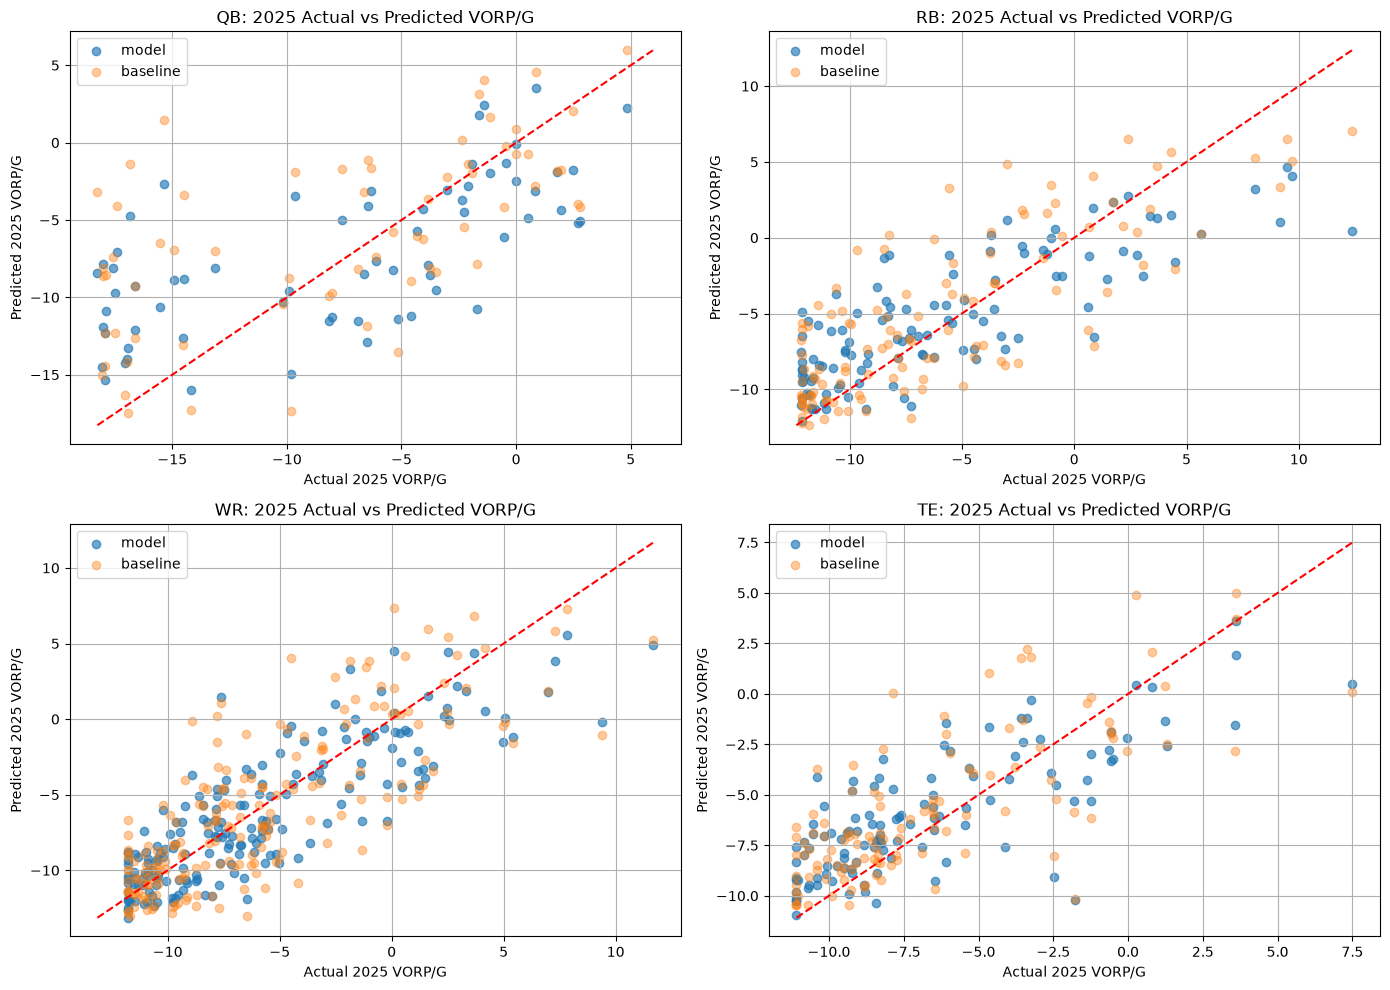

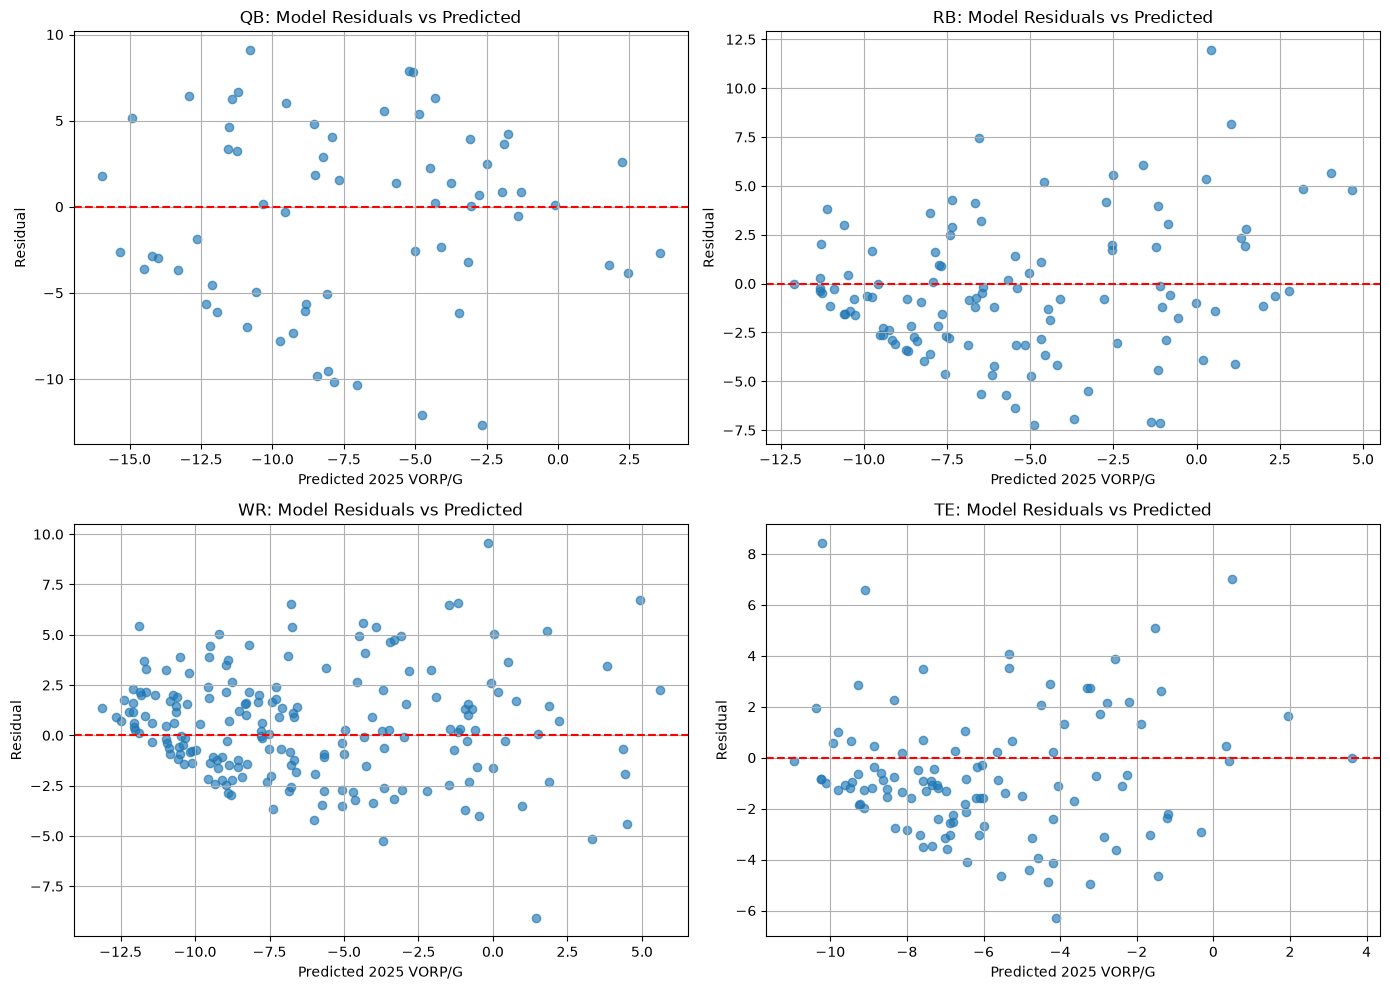

In [79]:
import matplotlib.pyplot as plt

positions = ["QB", "RB", "WR", "TE"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis, position in zip(axes.flatten(), positions):
    position_df = final_test_predictions_2025[
        final_test_predictions_2025["position"] == position
    ]
    axis.scatter(
        position_df["true_vorp_per_game"],
        position_df["model_pred_vorp_per_game"],
        alpha=0.65,
        label="model",
    )
    axis.scatter(
        position_df["true_vorp_per_game"],
        position_df["baseline_pred_vorp_per_game"],
        alpha=0.4,
        label="baseline",
    )
    min_value = min(
        position_df["true_vorp_per_game"].min(),
        position_df["model_pred_vorp_per_game"].min(),
        position_df["baseline_pred_vorp_per_game"].min(),
    )
    max_value = max(
        position_df["true_vorp_per_game"].max(),
        position_df["model_pred_vorp_per_game"].max(),
        position_df["baseline_pred_vorp_per_game"].max(),
    )
    axis.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")
    axis.set_title(f"{position}: 2025 Actual vs Predicted VORP/G")
    axis.set_xlabel("Actual 2025 VORP/G")
    axis.set_ylabel("Predicted 2025 VORP/G")
    axis.legend()
    axis.grid(True)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis, position in zip(axes.flatten(), positions):
    position_df = final_test_predictions_2025[
        final_test_predictions_2025["position"] == position
    ]
    axis.scatter(
        position_df["model_pred_vorp_per_game"],
        position_df["residual"],
        alpha=0.65,
    )
    axis.axhline(0, color="red", linestyle="--")
    axis.set_title(f"{position}: Model Residuals vs Predicted")
    axis.set_xlabel("Predicted 2025 VORP/G")
    axis.set_ylabel("Residual")
    axis.grid(True)

plt.tight_layout()
plt.show()
